In [1]:
import pandas as pd

train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")

In [ ]:
#1. Remove unnecessary columns

train = train.drop(
['CustomerID','Surname'],
axis=1
)

test = test.drop(
['CustomerID','Surname'],
axis=1
)

In [3]:
#2. Encode categorical variables

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical = [
'Region',
'Gender'
]

for col in categorical:

    train[col] = encoder.fit_transform(
        train[col]
    )

    test[col] = encoder.transform(
        test[col]
    )

In [4]:
#3. Create business features
#Customer Value Score:

train['CustomerValue'] = \
train['MonthlyCharge'] * \
train['NumOfProducts']

test['CustomerValue'] = \
test['MonthlyCharge'] * \
test['NumOfProducts']

In [5]:
#Usage Per Product:

train['UsagePerProduct'] = \
train['EstimatedMonthlyUsage'] / \
(train['NumOfProducts']+1)

test['UsagePerProduct'] = \
test['EstimatedMonthlyUsage'] / \
(test['NumOfProducts']+1)

In [6]:
#Tenure Group:
train['TenureGroup'] = pd.cut(
train['Tenure'],
bins=[0,2,5,10,100],
labels=[0,1,2,3]
)

test['TenureGroup'] = pd.cut(
test['Tenure'],
bins=[0,2,5,10,100],
labels=[0,1,2,3]
)

In [8]:
#Convert:

train['TenureGroup'] = pd.cut(
    train['Tenure'],
    bins=[-1,2,5,10,100],
    labels=[0,1,2,3]
)

test['TenureGroup'] = pd.cut(
    test['Tenure'],
    bins=[-1,2,5,10,100],
    labels=[0,1,2,3]
)

In [9]:
train['TenureGroup'].isnull().sum()

np.int64(0)

In [10]:
train['TenureGroup'] = \
train['TenureGroup'].astype(int)

test['TenureGroup'] = \
test['TenureGroup'].astype(int)

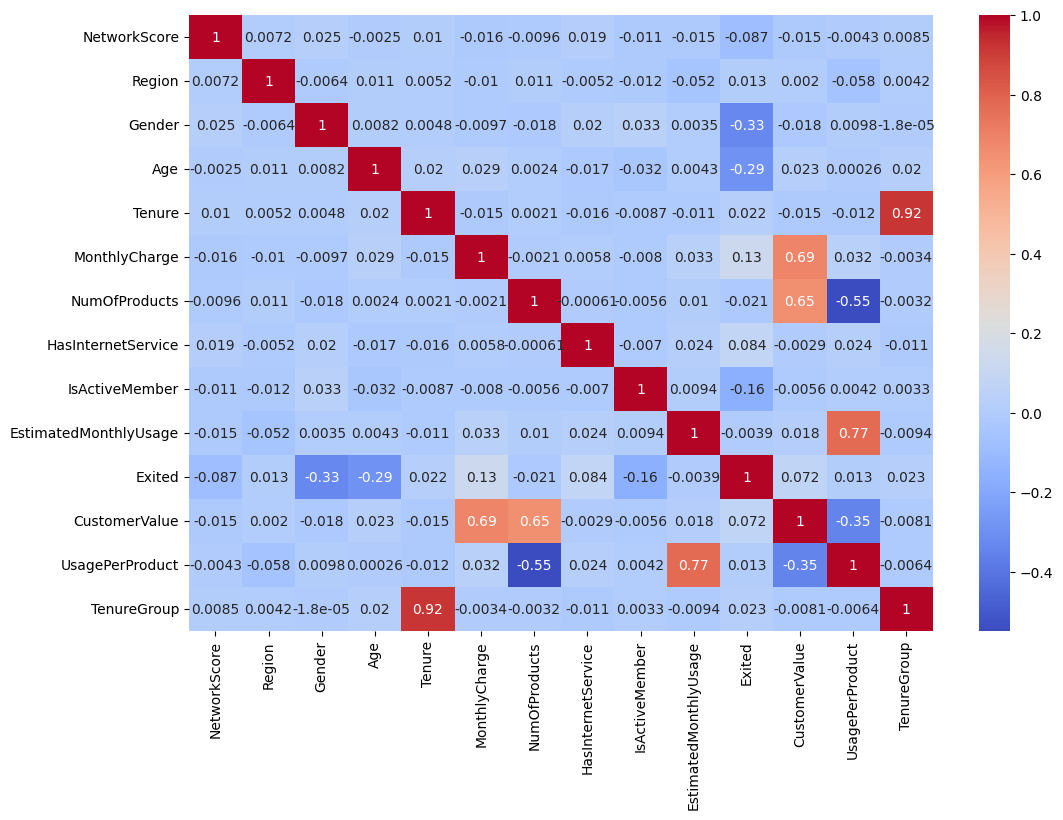

In [11]:
#4. Correlation check

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
train.corr(),
annot=True,
cmap='coolwarm'
)

plt.show()